In [1]:
#importing Necessary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [2]:
insurance_data = pd.read_csv('insurance.csv')

In [3]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
insurance_data.shape

(1338, 7)

In [7]:
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Figure size 432x432 with 0 Axes>

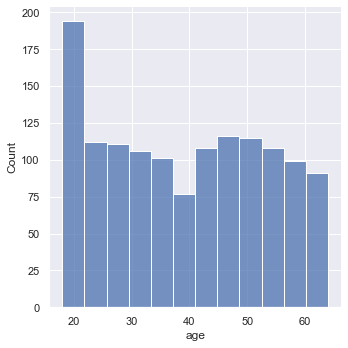

In [8]:
#Data Distribution for Numerical Column - Age
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_data['age'])
plt.show()

In [9]:
insurance_data['age'].value_counts()

18    69
19    68
51    29
45    29
46    29
47    29
48    29
50    29
52    29
20    29
26    28
54    28
53    28
25    28
24    28
49    28
23    28
22    28
21    28
27    28
28    28
31    27
29    27
30    27
41    27
43    27
44    27
40    27
42    27
57    26
34    26
33    26
32    26
56    26
55    26
59    25
58    25
39    25
38    25
35    25
36    25
37    25
63    23
60    23
61    23
62    23
64    22
Name: age, dtype: int64

<Figure size 432x432 with 0 Axes>

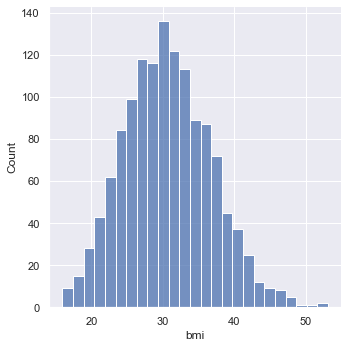

In [10]:
#Data Distribution for Numerical Column - BMI
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_data['bmi'])
plt.show()

<Figure size 432x432 with 0 Axes>

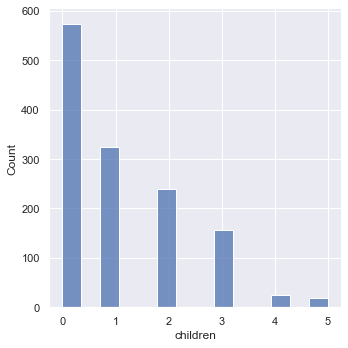

In [11]:
#Data Distribution for Numerical Column - children
sns.set()
plt.figure(figsize=(6,6))
sns.displot(insurance_data['children'])
plt.show()

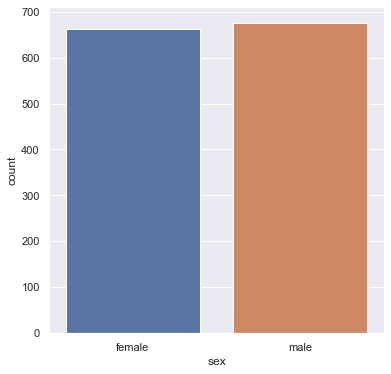

In [12]:
#Column charts for Categorical Column - sex
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x= insurance_data['sex'], data = insurance_data)
plt.show()

In [13]:
insurance_data['sex'].value_counts()

male      676
female    662
Name: sex, dtype: int64

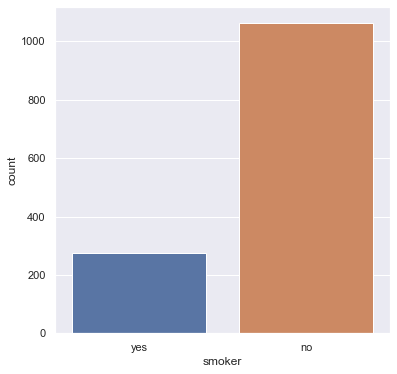

In [14]:
#Column charts for Categorical Column - smoker
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x= insurance_data['smoker'], data = insurance_data)
plt.show()

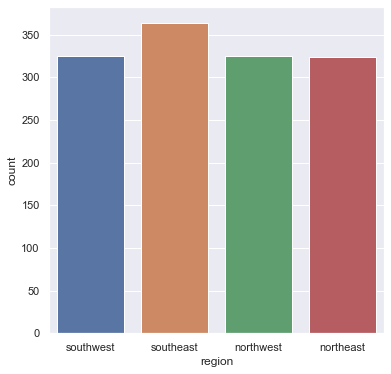

In [15]:
#Column charts for Categorical Column - region
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x= insurance_data['region'], data = insurance_data)
plt.show()

In [16]:
insurance_data['region'].value_counts()

southeast    364
southwest    325
northwest    325
northeast    324
Name: region, dtype: int64

In [17]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [18]:
#Converting Categorical Columns into Numerical Columns

insurance_data.replace({'sex':{'female':0, 'male':1}}, inplace=True)

insurance_data.replace({'smoker':{'no':0, 'yes':1}}, inplace=True)

insurance_data.replace({'region':{'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3}}, inplace=True)

In [19]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,1,16884.92400
1,18,1,33.770,1,0,0,1725.55230
2,28,1,33.000,3,0,0,4449.46200
3,33,1,22.705,0,0,3,21984.47061
4,32,1,28.880,0,0,3,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,3,10600.54830
1334,18,0,31.920,0,0,2,2205.98080
1335,18,0,36.850,0,0,0,1629.83350
1336,21,0,25.800,0,0,1,2007.94500


In [20]:
input_data = insurance_data.drop(columns='charges')
output_data = insurance_data['charges']

In [21]:
input_data

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,1
1,18,1,33.770,1,0,0
2,28,1,33.000,3,0,0
3,33,1,22.705,0,0,3
4,32,1,28.880,0,0,3
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,3
1334,18,0,31.920,0,0,2
1335,18,0,36.850,0,0,0
1336,21,0,25.800,0,0,1


In [22]:
output_data

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [23]:
input_train_data, input_test_data, output_train_data, output_test_data = train_test_split(input_data, output_data, test_size=0.2)

In [24]:
print(input_data.shape, input_train_data.shape, input_test_data.shape)

(1338, 6) (1070, 6) (268, 6)


In [25]:
print(output_data.shape, output_train_data.shape, output_test_data.shape)

(1338,) (1070,) (268,)


In [26]:
#Model Creation 

model = RandomForestRegressor(n_estimators=100, max_depth=7)

In [27]:
#Training Model

model.fit(input_train_data, output_train_data)

RandomForestRegressor(max_depth=7)

In [28]:
#predicting values with Test Dataset

test_data_predictions = model.predict(input_test_data) 

In [29]:
#Evaluating Model

from sklearn.metrics import r2_score

In [30]:
r2_score(test_data_predictions,output_test_data)

0.8805769405580862

In [31]:
#age	sex	bmi	children	smoker	region
input_data = (35, 1,35, 1, 0, 0)
input_data_array = np.asarray(input_data)
input_data_array = input_data_array.reshape(1,-1)

In [32]:
insurance_premium = model.predict(input_data_array)

In [33]:
insurance_premium[0]

5836.135060232514

In [ ]:
import joblib


In [ ]:
joblib.dump(model, 'model_insurance.pkl')


['model_insurance.pkl']